In [8]:
#Import libraries

import pandas as pd
import numpy as np
from scipy import stats

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [9]:
#Load and inspect
df = pd.read_csv("D:\ecommerce_sales_analytics_5000.csv")

In [11]:
df.shape

(5000, 12)

In [12]:
#dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   object 
 4   region            5000 non-null   object 
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   object 
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), object(4)
memory usage: 468.9+ KB


In [13]:
#datset type
df.dtypes

order_id              int64
order_date           object
customer_id           int64
product_category     object
region               object
quantity              int64
unit_price          float64
discount            float64
payment_method       object
delivery_days         int64
customer_rating     float64
revenue             float64
dtype: object

In [18]:
#null values
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [22]:
##converting column from string to real date type
pd.to_datetime(df["order_date"])

0      2022-01-01
1      2022-01-02
2      2022-01-03
3      2022-01-04
4      2022-01-05
          ...    
4995   2035-09-05
4996   2035-09-06
4997   2035-09-07
4998   2035-09-08
4999   2035-09-09
Name: order_date, Length: 5000, dtype: datetime64[ns]

In [39]:
##find rows with dates beyond 2024 (anomaly) 

df["order_date"]=pd.to_datetime(df["order_date"],errors="coerce")
bad_dates =df[df["order_date"].dt.year>2024]
print(f"Bad date rows found: {len(bad_dates)}")
print("\nSample of bad rows:")
print(bad_dates[["order_id","order_date","revenue"]].head(5))

Bad date rows found: 3904

Sample of bad rows:
      order_id order_date  revenue
1096     11097 2025-01-01  3170.45
1097     11098 2025-01-02   681.20
1098     11099 2025-01-03   740.39
1099     11100 2025-01-04   567.40
1100     11101 2025-01-05    96.75


In [40]:
#removing bad dates
df_clean = df[df['order_date'].dt.year <= 2024].copy()
print(f"\nClean dataset size: {len(df_clean)} rows")


Clean dataset size: 1096 rows


In [43]:
#Calculating Revnue
df_clean['calc_revenue'] = ( df_clean['unit_price'] * df_clean['quantity'] * (1 - df_clean['discount']) ).round(2)

In [49]:
#Calculated revnue is different from Actual one or not?
df_clean['revenue_match'] = ( abs(df_clean['revenue'] - df_clean['calc_revenue']) < 0.05 )
mismatches = df_clean[df_clean['revenue_match'] == False]
print(f"Revenue mismatches: {len(mismatches)}")
if len(mismatches) > 0:
 print(mismatches[['order_id','revenue','calc_revenue']].head())

Revenue mismatches: 0


In [61]:
##Outliers Detection using IQR 
for col in ['revenue', 'unit_price', 'delivery_days']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    out = df_clean[ (df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(out)} outliers | range: {lower:.1f} to {upper:.1f}")

revenue: 19 outliers | range: -1342.6 to 3171.9
unit_price: 0 outliers | range: -302.2 to 910.1
delivery_days: 0 outliers | range: -3.5 to 16.5


In [71]:
#Exactracting features of time from order_date
df_clean['month'] = df_clean['order_date'].dt.month
df_clean['month_name'] = df_clean['order_date'].dt.strftime('%b')
df_clean['quarter'] = df_clean['order_date'].dt.quarter
df_clean['year'] = df_clean['order_date'].dt.year
df_clean['day_of_week'] = df_clean['order_date'].dt.day_name()
print("Time columns added. Sample:")
print(df_clean[['order_date','month','month_name','quarter','day_of_week']].head(3))

Time columns added. Sample:
  order_date  month month_name  quarter day_of_week
0 2022-01-01      1        Jan        1    Saturday
1 2022-01-02      1        Jan        1      Sunday
2 2022-01-03      1        Jan        1      Monday


In [73]:
##discount_bucket and delivery_speed
df_clean['discount_bucket'] = pd.cut( df_clean['discount'], bins=[-0.01, 0, 0.15, 0.30, 1.0], labels=['No discount','Low','Medium','High'] )
df_clean['delivery_speed'] = pd.cut( df_clean['delivery_days'], bins=[0, 4, 8, 100], labels=['Fast','Standard','Slow'] )
print(df_clean['discount_bucket'].value_counts())
print()
print(df_clean['delivery_speed'].value_counts())

discount_bucket
Medium         500
Low            436
High           147
No discount     13
Name: count, dtype: int64

delivery_speed
Fast        395
Standard    393
Slow        308
Name: count, dtype: int64


In [81]:
###flag repeats customers
order_counts = df_clean.groupby("customer_id")["order_id"].count()

In [78]:
df_clean['order_count'] = df_clean['customer_id'].map(order_counts)
df_clean['is_repeat_customer'] = df_clean['order_count'] > 1
print("Repeat customers:", df_clean['is_repeat_customer'].sum())
print("One-time customers:", (~df_clean['is_repeat_customer']).sum())

Repeat customers: 765
One-time customers: 331


In [82]:
####FINAL COLUMN LIST
print("Final columns:")
print(df_clean.columns.tolist())
print(f"\nFinal shape: {df_clean.shape}")

Final columns:
['order_id', 'order_date', 'customer_id', 'product_category', 'region', 'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days', 'customer_rating', 'revenue', 'calc_revenue', 'revenue_match', 'month', 'month_name', 'quarter', 'year', 'day_of_week', 'discount_bucket', 'delivery_speed', 'order_count', 'is_repeat_customer']

Final shape: (1096, 23)


In [83]:
####SAVING CLEAN CSV FILE
df_clean.to_csv('ecommerce_clean.csv', index=False)
print("\nSaved: ecommerce_clean.csv")
print("This file is ready for: EDA notebook + Power BI")


Saved: ecommerce_clean.csv
This file is ready for: EDA notebook + Power BI


In [ ]:
#############VISUALIZATION###############


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)


In [12]:

df = pd.read_csv("ecommerce_clean.csv")
df['order_date'] = pd.to_datetime(df['order_date'])
df = df[df['order_date'].dt.year <= 2024].copy()
df['month'] = df['order_date'].dt.to_period('M').astype(str)
df['quarter'] = df['order_date'].dt.quarter
print(df.shape)

(1096, 23)


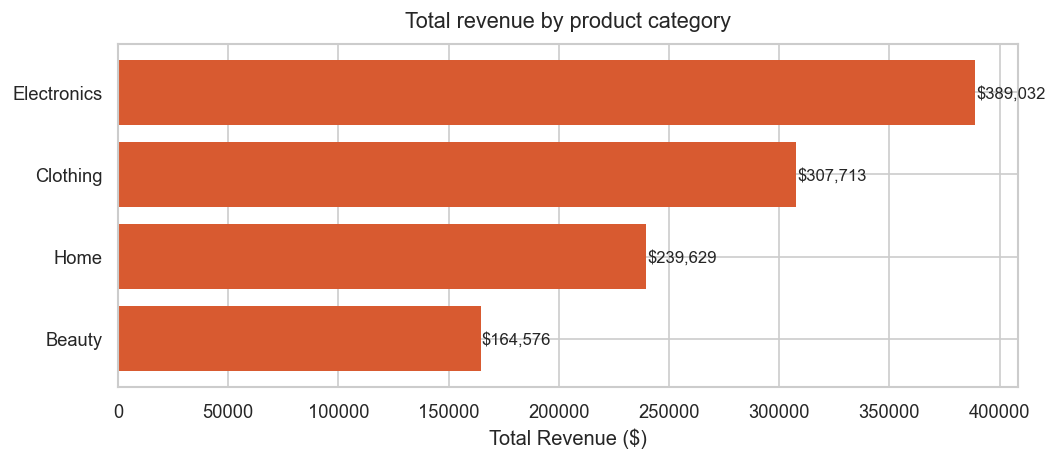

In [13]:
# Chart 1: Revenue by product category

cat_rev = df.groupby('product_category')['revenue'].sum().sort_values()

fig, ax = plt.subplots(figsize=(9,4))
bars = ax.barh(cat_rev.index, cat_rev.values, color='#D85A30', edgecolor='none')

for bar in bars:
    ax.text(bar.get_width() + 500,
            bar.get_y() + bar.get_height()/2,
            f'${bar.get_width():,.0f}', va='center', fontsize=10)

ax.set_xlabel('Total Revenue ($)')
ax.set_title('Total revenue by product category', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('chart1_revenue_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 1: Revenue by product category


- Electronics leads with **$389K (35.3%)** of total revenue, but Beauty has the highest avg order value at **$1,090/order**. - Clothing + Home together = **49.7%** of revenue — the business is not over-reliant on one category.
-  **Recommendation:**
-  Investigate why Beauty generates fewer orders despite highest avg value — is it a discovery/marketing problem?

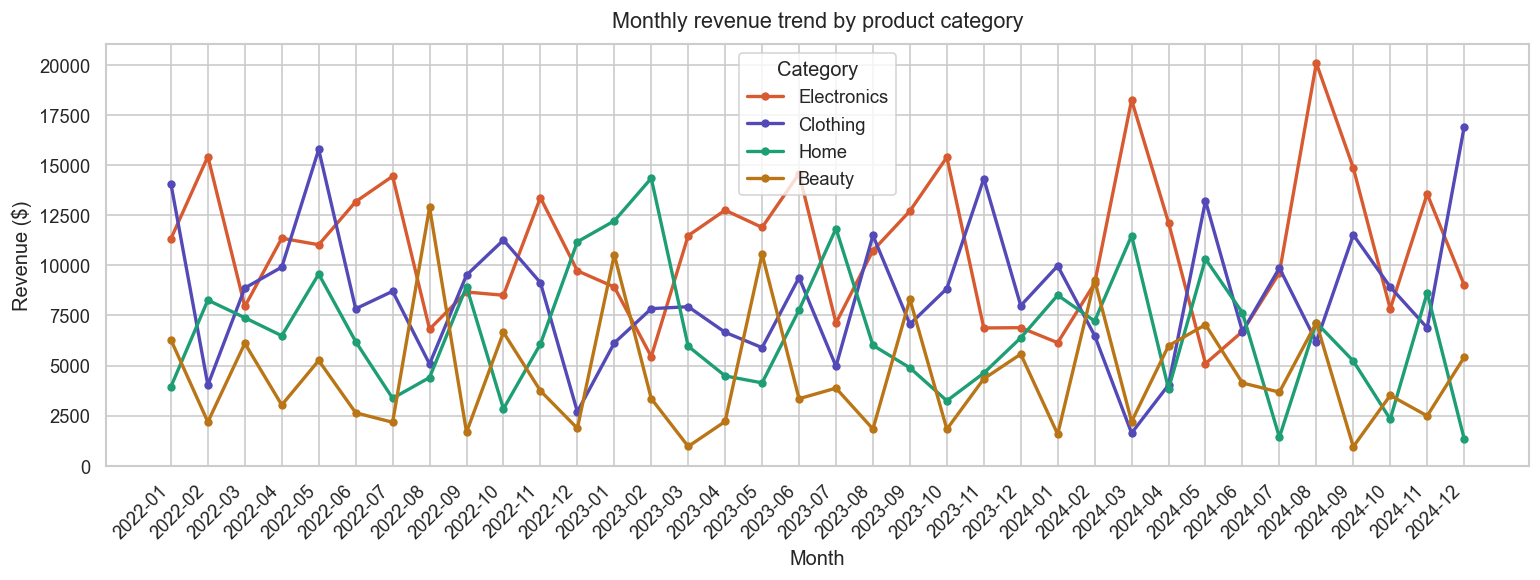

In [14]:
# Chart 2: Monthly revenue trend by category

monthly = (df.groupby(['month','product_category'])['revenue']
             .sum().reset_index().sort_values('month'))

fig, ax = plt.subplots(figsize=(13,5))
categories = ['Electronics','Clothing','Home','Beauty']
colors     = ['#D85A30','#534AB7','#1D9E75','#BA7517']

for cat, color in zip(categories, colors):
    data = monthly[monthly['product_category']==cat]
    ax.plot(data['month'], data['revenue'],
            marker='o', label=cat, color=color,
            linewidth=2, markersize=4)

ax.set_xlabel('Month')
ax.set_ylabel('Revenue ($)')
ax.set_title('Monthly revenue trend by product category', fontsize=13, pad=10)
ax.legend(title='Category')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('chart2_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# Chart 2: Monthly revenue trend by category
- Revenue peaked at **$41,629 in May 2022**
and hit its lowest point at **$22,583 in Oct 2024** — a 46% swing.
- **Electronics** is the most volatile category (std = $3,620), meaning demand spikes and drops sharply month to month.
- **Action:**
- Seasonal patterns need further investigation do peaks align with holidays or promotions?

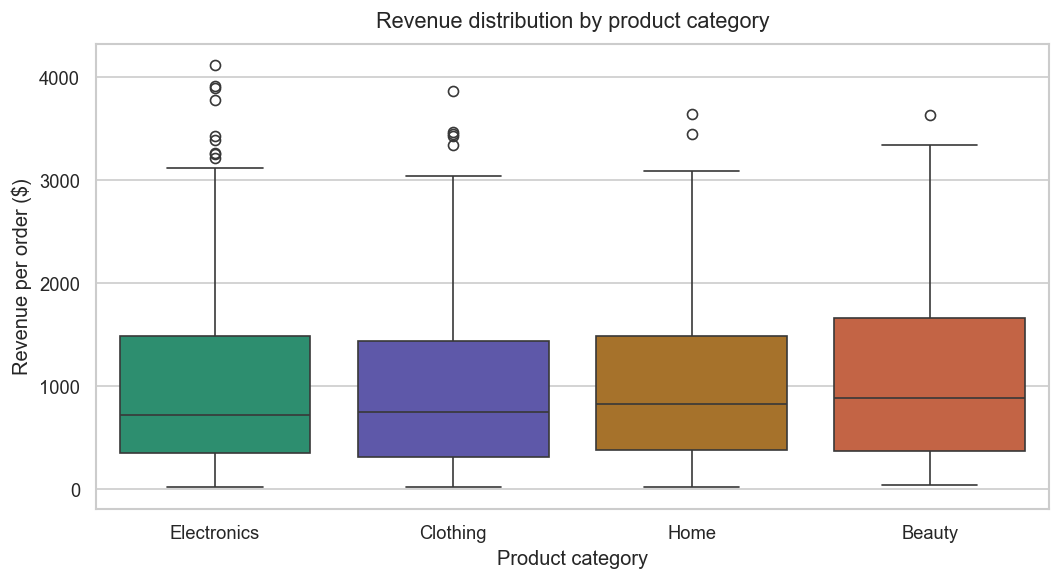

In [16]:
# Chart 3: Box plot — revenue spread per category

fig, ax = plt.subplots(figsize=(9,5))

sns.boxplot(
    data=df,
    x='product_category',
    y='revenue',
    hue='product_category',         
    palette=['#D85A30','#534AB7','#1D9E75','#BA7517'],
    order=['Electronics','Clothing','Home','Beauty'],
    dodge=False,                     
    legend=False,                   
    ax=ax
)

ax.set_xlabel('Product category')
ax.set_ylabel('Revenue per order ($)')
ax.set_title('Revenue distribution by product category', fontsize=13, pad=10)

plt.tight_layout()
plt.savefig('chart4_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3 — Revenue Distribution by Category
- **Beauty has the highest median order value ($883)** despite fewest orders — it attracts high-value buyers.
- **Electronics median is $720 but mean is $1,003** large outlier orders skew the average upward significantly.
- All categories show right-skewed distributions, meaning a few large orders heavily influence total revenue in each segment.

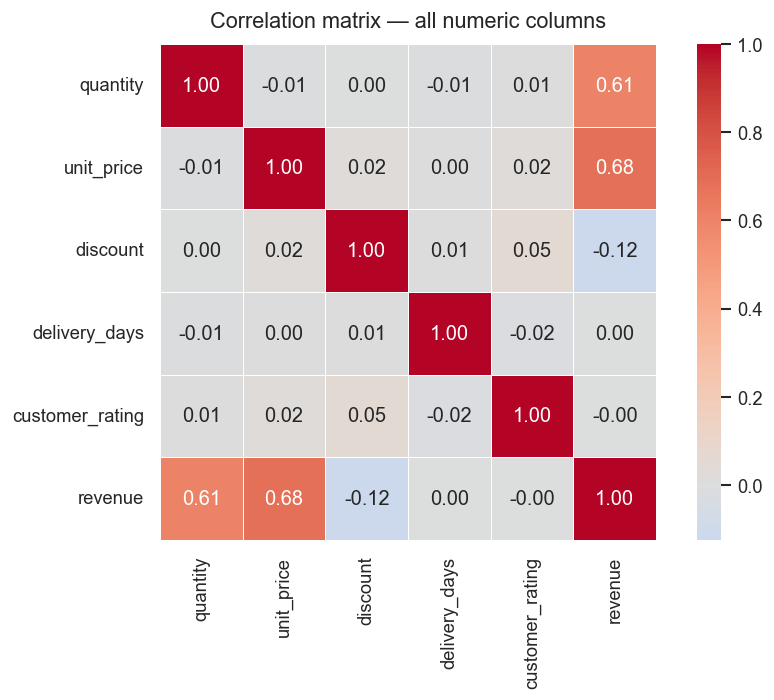

In [20]:
# Chart 4: Correlation heatmap

numeric_cols = ['quantity','unit_price','discount',
               'delivery_days','customer_rating','revenue']
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=0.5,
            ax=ax)
ax.set_title('Correlation matrix — all numeric columns', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('chart3_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4 — Correlation Heatmap

 - Revenue is driven mainly by **unit_price (r=0.68)** and **quantity (r=0.61)** — both factors carry similar weight.
- **Discount negatively correlates with revenue (r=-0.125)** — discounting does not generate enough volume to compensate for the margin loss. - -------- Delivery days vs customer rating correlation = **-0.020** — effectively zero.
- Customers rate based on other factors, not speed.

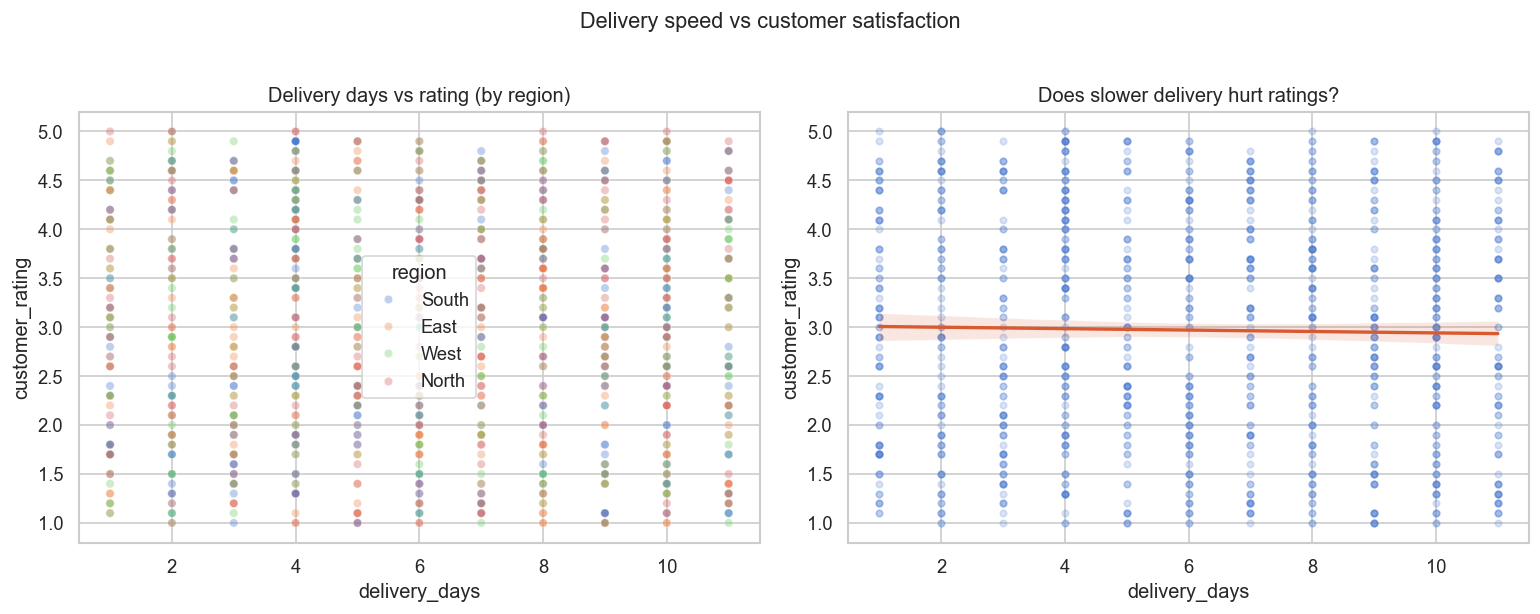

In [25]:
# Chart 5: Delivery vs rating — scatter + regression

fig, axes = plt.subplots(1,2, figsize=(13,5))

# Left: colored by region
sns.scatterplot(data=df,
               x='delivery_days', y='customer_rating',
               hue='region', alpha=0.35, s=25,
               ax=axes[0])
axes[0].set_title('Delivery days vs rating (by region)')

# Right: regression trend line
sns.regplot(data=df,
            x='delivery_days', y='customer_rating',
            scatter_kws={'alpha':0.2, 's':15},
            line_kws={'color':'#D85A30', 'linewidth':2},
            ax=axes[1])
axes[1].set_title('Does slower delivery hurt ratings?')

plt.suptitle('Delivery speed vs customer satisfaction', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('chart5_delivery_vs_rating.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5 — Delivery Days vs Customer Rating
- **T-test result: p = 0.199**  delivery speed does NOT significantly affect customer rating. The hypothesis is rejected.
- All 4 regions have nearly identical avg delivery times (~6.0–6.3 days) and avg ratings (~2.93–3.00).
- **Key concern:**
  -Avg rating of ~2.97/5 is below the midpoint the driver of dissatisfaction is not delivery speed and needs further investigation.

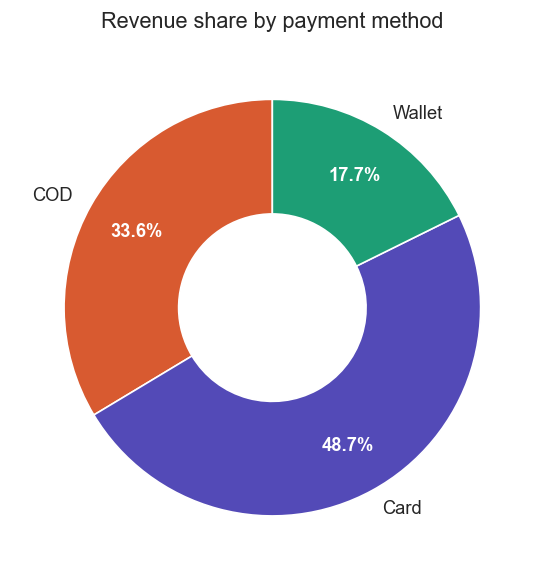

In [18]:
# Chart 6: Payment method 

pay_rev = df.groupby('payment_method')['revenue'].sum()

fig, ax = plt.subplots(figsize=(7,5))
wedges, texts, autotexts = ax.pie(
    pay_rev.values,
    labels=pay_rev.index,
    autopct='%1.1f%%',
    colors=['#D85A30','#534AB7','#1D9E75'],
    wedgeprops=dict(width=0.55),
    startangle=90,
    pctdistance=0.75
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_color('white')
    t.set_fontweight('bold')

ax.set_title('Revenue share by payment method', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('chart6_payment_donut.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 6 — Payment Method Revenue Share 
-*Card = 48.7% of revenue ($536K)*  with highest avg order value ($1,074). Most impactful payment channel.
- **COD has the slowest delivery (6.48 days)**  yet holds 33.6% revenue share. Customers accept slower delivery for COD.
- **Wallet users have the highest satisfaction (3.06) but lowest share (17.7%)** opportunity to grow this channel through incentives.

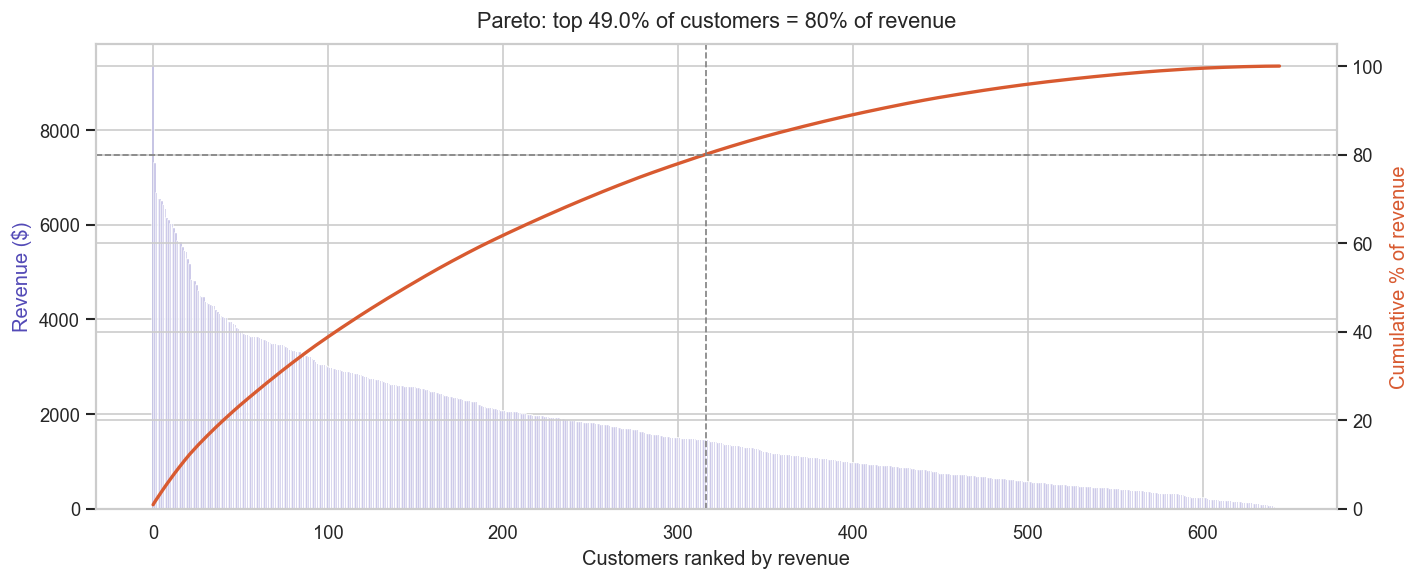

80% of revenue comes from 49.0% of customers


In [19]:
#Chart 7: Pareto — customer revenue concentration

cust_rev = (df.groupby('customer_id')['revenue']
              .sum().sort_values(ascending=False).reset_index())

cust_rev['cumulative_pct'] = (cust_rev['revenue'].cumsum()
                               / cust_rev['revenue'].sum() * 100)

idx_80      = (cust_rev['cumulative_pct'] >= 80).idxmax()
pct_custs   = idx_80 / len(cust_rev) * 100

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(range(len(cust_rev)), cust_rev['revenue'],
        color='#534AB7', alpha=0.7)
ax1.set_xlabel('Customers ranked by revenue')
ax1.set_ylabel('Revenue ($)', color='#534AB7')

ax2 = ax1.twinx()
ax2.plot(range(len(cust_rev)), cust_rev['cumulative_pct'],
         color='#D85A30', linewidth=2)
ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1)
ax2.axvline(x=idx_80, color='gray', linestyle='--', linewidth=1)
ax2.set_ylabel('Cumulative % of revenue', color='#D85A30')
ax2.set_ylim(0,105)

ax1.set_title(
    f'Pareto: top {pct_custs:.1f}% of customers = 80% of revenue',
    fontsize=13, pad=10
)
plt.tight_layout()
plt.savefig('chart7_pareto.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'80% of revenue comes from {pct_custs:.1f}% of customers')

## Chart 7 — Pareto: Customer Revenue Concentration 
- **49% of customers (316 out of 645) drive 80% of revenue** distribution is more even than the classic 80/20 rule. 
- **Top 10% of customers (65 people) = 27.7% of total revenue** — high-value customer retention is critical.
- Repeat customers (314) generate **2.24× more total revenue** than one-time customers (331) despite similar counts.